# RideShare SQL Dataset — Practice Notebook

Welcome! This notebook gives you **60 progressive SQL challenges** across three difficulty levels,
using a synthetic ride-sharing database modelled on platforms like Uber/Lyft.

## How to use this notebook

> **Direct SQL with `%%sql` magic** — every practice cell uses the `%%sql` cell magic, which
> renders query results as a nicely formatted table right inside the notebook.
> You write raw SQL — no Python string wrapping needed.

| Level | Questions | Focus |
|-------|-----------|-------|
| Beginner | B1 – B20 | SELECT, WHERE, ORDER BY, LIMIT, basic aggregates |
| Intermediate | I1 – I22 | GROUP BY, JOINs, HAVING, subqueries, date functions |
| Advanced | A1 – A18 | Window functions, CTEs, self-joins, business analytics |

---


## Setup — run these cells once before anything else

Choose **one** of the three engine blocks below (SQLite, PostgreSQL, or MySQL).
The rest of the notebook uses standard SQL that works across all three engines.

> **Engine notes**
> - **SQLite** — zero-install, works on Kaggle and locally; uses `STRFTIME()` for dates.
> - **PostgreSQL** — replace `STRFTIME('%Y-%m', col)` → `TO_CHAR(col, 'YYYY-MM')` and `JULIANDAY` differences → `EXTRACT(EPOCH FROM …)/60`.
> - **MySQL** — replace `STRFTIME('%Y-%m', col)` → `DATE_FORMAT(col, '%Y-%m')` and use `TIMESTAMPDIFF(MINUTE, a, b)` instead of JULIANDAY arithmetic.


In [1]:
# Step 1 — install ipython-sql (Kaggle already has it, run if missing locally)
!pip install ipython-sql --quiet

print("Install successful")

Install successful


In [2]:
import prettytable
import sql.run as sqlrun

# Find a working style dynamically — no hardcoding
def _get_valid_style():
    for candidate in ['SINGLE_BORDER', 'MARKDOWN', 'PLAIN_COLUMNS', 'ORGMODE', 'MSWORD_FRIENDLY']:
        if hasattr(prettytable, candidate):
            return candidate
    # Last resort: grab the first uppercase attribute
    for name in dir(prettytable):
        if name.isupper() and isinstance(getattr(prettytable, name), int):
            return name

SAFE_STYLE = _get_valid_style()
print(f"Using style: {SAFE_STYLE}")

if not getattr(sqlrun.ResultSet, '_style_patched', False):
    import inspect
    # Get the true original source function to avoid recursion
    _true_original = None
    for cls in sqlrun.ResultSet.__mro__:
        if '__init__' in cls.__dict__:
            _true_original = cls.__dict__['__init__']
            break

    def _patched_init(self, sqlaproxy, config):
        if hasattr(config, 'style'):
            config.style = SAFE_STYLE
        _true_original(self, sqlaproxy, config)

    sqlrun.ResultSet.__init__ = _patched_init
    sqlrun.ResultSet._style_patched = True
    print("Patch applied")
else:
    print("Already patched")

%config SqlMagic.style = SAFE_STYLE



# Keeps ipython-sql's own config consistent with what the patch enforces,
# so both layers agree on the style.

# It surgically intercepts every %%sql 
# result object at construction time and forces a valid table style,
# working around the prettytable v3.x breaking change — without touching any of your SQL cells.

Using style: SINGLE_BORDER
Patch applied


/tmp/ipykernel_17/4287018435.py:7: DeprecationWarning: the 'SINGLE_BORDER' constant is deprecated, use the 'TableStyle' enum instead
  if hasattr(prettytable, candidate):


###  Step 2 — Connect to your database engine

Run **only one** of the cells below.


In [3]:
# ── Option A: SQLite (default — works on Kaggle & locally) ────────────────
import sqlite3, os
import pandas as pd

%load_ext sql

# Auto-detect Kaggle vs local path
KAGGLE_DB = "/kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db"
LOCAL_DB  = "rideshare.db"
DB_PATH   = KAGGLE_DB if os.path.exists(KAGGLE_DB) else LOCAL_DB

%sql sqlite:///{DB_PATH}

# Pandas helper for EDA sections
conn = sqlite3.connect(DB_PATH)
def q(sql): return pd.read_sql_query(sql, conn)

print(f"Connected to SQLite: {DB_PATH} ")


Connected to SQLite: /kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db 


In [4]:
# ── Option B: PostgreSQL ──────────────────────────────────────────────────
# Requires: pip install psycopg2-binary ipython-sql
# First import schema.sql:  psql -U <user> -d <dbname> -f schema.sql
#
# import pandas as pd
# %load_ext sql
#
# PG_USER = "your_user"
# PG_PASS = "your_password"
# PG_HOST = "localhost"
# PG_PORT = "5432"
# PG_DB   = "rideshare"
#
# %sql postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}
#
# import psycopg2
# conn = psycopg2.connect(user=PG_USER, password=PG_PASS,
#                         host=PG_HOST, port=PG_PORT, dbname=PG_DB)
# def q(sql):
#     import pandas as pd
#     return pd.read_sql_query(sql, conn)
#
# print("Connected to PostgreSQL")
#
#  Date-function substitutions for PostgreSQL:
#   STRFTIME('%Y-%m', col)       →  TO_CHAR(col, 'YYYY-MM')
#   STRFTIME('%H',    col)       →  TO_CHAR(col, 'HH24')
#   JULIANDAY(b)-JULIANDAY(a)    →  EXTRACT(EPOCH FROM (b::timestamp - a::timestamp))
#   DATE(col)                    →  col::date
print("Uncomment the lines above to use PostgreSQL.")


Uncomment the lines above to use PostgreSQL.


In [5]:
# ── Option C: MySQL ───────────────────────────────────────────────────────
# Requires: pip install pymysql ipython-sql
# First import schema.sql:  mysql -u <user> -p <dbname> < schema.sql
#
# import pandas as pd
# %load_ext sql
#
# MY_USER = "your_user"
# MY_PASS = "your_password"
# MY_HOST = "localhost"
# MY_PORT = "3306"
# MY_DB   = "rideshare"
#
# %sql mysql+pymysql://{MY_USER}:{MY_PASS}@{MY_HOST}:{MY_PORT}/{MY_DB}
#
# import pymysql
# conn = pymysql.connect(user=MY_USER, password=MY_PASS,
#                        host=MY_HOST, port=int(MY_PORT), database=MY_DB)
# def q(sql):
#     import pandas as pd
#     return pd.read_sql_query(sql, conn)
#
# print("Connected to MySQL ")
#
#  Date-function substitutions for MySQL:
#   STRFTIME('%Y-%m', col)       →  DATE_FORMAT(col, '%Y-%m')
#   STRFTIME('%H',    col)       →  HOUR(col)
#   JULIANDAY difference * 1440  →  TIMESTAMPDIFF(MINUTE, a, b)
#   DATE(col)                    →  DATE(col)   ← same!
print("Uncomment the lines above to use MySQL.")


Uncomment the lines above to use MySQL.


## Schema Overview

| Table | Description |
|-------|-------------|
| `users` | Every person on the platform (drivers + riders share this) |
| `drivers` | Extended profile for users who drive |
| `riders` | Extended profile for users who take rides |
| `locations` | Zone/area lookup — 40 zones across 4 cities |
| `trips` | Core fact table — one row per ride request |
| `payments` | One payment per completed trip |
| `reviews` | Bidirectional ratings — riders rate drivers, drivers rate riders |
| `cancellations` | One row per cancelled trip |

Run the cell below to inspect row counts across all tables.


In [6]:
%%sql
SELECT 'users'         AS tbl, COUNT(*) AS rows FROM users        UNION ALL
SELECT 'drivers',               COUNT(*)         FROM drivers       UNION ALL
SELECT 'riders',                COUNT(*)         FROM riders        UNION ALL
SELECT 'locations',             COUNT(*)         FROM locations     UNION ALL
SELECT 'trips',                 COUNT(*)         FROM trips         UNION ALL
SELECT 'payments',              COUNT(*)         FROM payments      UNION ALL
SELECT 'reviews',               COUNT(*)         FROM reviews       UNION ALL
SELECT 'cancellations',         COUNT(*)         FROM cancellations;


 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


tbl,rows
users,2000
drivers,400
riders,1600
locations,40
trips,20000
payments,16827
reviews,15136
cancellations,2966


---
#  Section 1 — Beginner

In this section you will practice the fundamental SQL building blocks:
`SELECT`, `WHERE`, `ORDER BY`, `LIMIT`, and basic aggregate functions
(`COUNT`, `SUM`, `AVG`, `MIN`, `MAX`). Every question targets a single table —
no joins required.


## B1 · List the first 10 trips ordered by requested_at

**Concept:** Basic `SELECT` with `ORDER BY` and `LIMIT` lets you peek at the most recent (or earliest) rows without reading the whole table.


In [7]:
%%sql

#Write code here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
(sqlite3.OperationalError) near "#Write": syntax error
[SQL: #Write code here]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


<details>
<summary> <b>Hint</b> — click to expand</summary>

Which table holds trip records? Use ORDER BY on the datetime column, then LIMIT the output.

</details>


<details>
<summary> <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM trips
ORDER BY requested_at
LIMIT 10;
```

**Technique:** ORDER BY defaults to ASC; add DESC to reverse the sort.

</details>


## B2 · How many total users are in the database?

**Concept:** `COUNT(*)` counts every row in the result set, making it ideal for quick size checks.


In [8]:
%%sql
--  Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

COUNT(*) on the users table returns all rows regardless of NULLs.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT COUNT(*) AS total_users
FROM users;
```

**Technique:** COUNT(*) ≠ COUNT(column) — the latter skips NULLs.

</details>


## B3 · Show all trips with a surge_multiplier greater than 2.0

**Concept:** The `WHERE` clause filters rows before any aggregation. Use comparison operators (`>`, `<`, `=`, `!=`, `BETWEEN`, `IN`) to narrow results.


In [9]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Which table contains surge_multiplier? What operator compares a value to 2.0?

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM trips
WHERE surge_multiplier > 2.0;
```

**Technique:** Simple WHERE filter with a numeric comparison operator.

</details>


## B4 · List all drivers who are currently inactive

**Concept:** Boolean columns (stored as 0/1) can be filtered with `= 0` or `= 1`.


In [10]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

The drivers table has an is_active column. Filter where it equals 0.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM drivers
WHERE is_active = 0;
```

**Technique:** In SQLite, FALSE = 0 and TRUE = 1.

</details>


## B5 · What are the distinct payment methods used?

**Concept:** `DISTINCT` removes duplicate values, giving you the unique set of values in a column.


In [11]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Use SELECT DISTINCT on the payment_method column inside the trips table.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT DISTINCT payment_method
FROM trips;
```

**Technique:** DISTINCT applies to the full row; add more columns to get unique combinations.

</details>


## B6 · Show all trips that were cancelled

**Concept:** String comparisons in WHERE use single quotes around the literal value.


In [12]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Filter trips WHERE status equals the string 'cancelled'.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM trips
WHERE status = 'cancelled';
```

**Technique:** String literals must use single quotes in standard SQL.

</details>


## B7 · Find all riders who joined in 2023

**Concept:** Date filtering with `STRFTIME` or string comparison on ISO dates works across SQLite, MySQL, and PostgreSQL.


In [13]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Use STRFTIME('%Y', created_at) = '2023' or compare created_at BETWEEN two dates.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM riders
WHERE STRFTIME('%Y', created_at) = '2023';
-- PostgreSQL: WHERE EXTRACT(YEAR FROM created_at) = 2023
```

**Technique:** ISO date strings sort correctly as text, enabling BETWEEN comparisons.

</details>


## B8 · Show the 5 most expensive trips by total_fare

**Concept:** Combine `ORDER BY column DESC` with `LIMIT n` to rank and slice the top rows.


In [14]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Sort the trips table by total_fare in descending order, then take the first 5.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM trips
ORDER BY total_fare DESC
LIMIT 5;
```

**Technique:** DESC reverses the sort so the largest value appears first.

</details>


## B9 · List all zones of type 'airport'

**Concept:** The locations table contains a zone_type column. Filtering with WHERE gives you the relevant subset.


In [15]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

SELECT from locations WHERE zone_type equals 'airport'.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM locations
WHERE zone_type = 'airport';
```

**Technique:** String comparisons are case-sensitive in most engines — match the exact casing in the data.

</details>


## B10 · How many trips were paid by cash?

**Concept:** `COUNT(*)` combined with a `WHERE` filter counts only rows matching your condition.


In [16]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Filter trips WHERE payment_method = 'cash', then count.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT COUNT(*) AS cash_trips
FROM trips
WHERE payment_method = 'cash';
```

**Technique:** Combine COUNT with WHERE — no GROUP BY needed for a single category.

</details>


## B11 · What is the longest trip by distance_km?

**Concept:** `MAX()` returns the single largest value in a numeric column.


In [17]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Use MAX(distance_km) from the trips table.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT MAX(distance_km) AS longest_trip_km
FROM trips;
```

**Technique:** To see the full row use ORDER BY distance_km DESC LIMIT 1.

</details>


## B12 · List all unique cities in the locations table

**Concept:** `DISTINCT` on a single column gives you a clean lookup of all unique values.


In [18]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

SELECT DISTINCT city FROM the locations table.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT DISTINCT city
FROM locations
ORDER BY city;
```

**Technique:** Adding ORDER BY makes the output alphabetically sorted for readability.

</details>


## B13 · How many drivers joined after January 1, 2023?

**Concept:** Date comparison uses `>` with an ISO string literal `'YYYY-MM-DD'`.


In [19]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Filter drivers WHERE join_date > '2023-01-01' and count them.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT COUNT(*) AS drivers_joined_2023_plus
FROM drivers
WHERE join_date > '2023-01-01';
```

**Technique:** ISO date strings compare correctly as text in SQLite.

</details>


## B14 · Find all payments that failed

**Concept:** The payments table has a status column. Filter for the literal string 'failed'.


In [20]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

WHERE status = 'failed' in the payments table.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM payments
WHERE status = 'failed';
```

**Technique:** Check distinct status values first with SELECT DISTINCT status FROM payments.

</details>


## B15 · List trips that have no completed_at value

**Concept:** `IS NULL` tests for missing values. `= NULL` does NOT work in SQL.


In [21]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

WHERE completed_at IS NULL checks for missing completion timestamps.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM trips
WHERE completed_at IS NULL;
```

**Technique:** Always use IS NULL / IS NOT NULL — never = NULL.

</details>


## B16 · How many reviews have a rating of 5?

**Concept:** Combine COUNT with a WHERE filter on an integer column.


In [22]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Filter reviews WHERE rating = 5, then count.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT COUNT(*) AS five_star_reviews
FROM reviews
WHERE rating = 5;
```

**Technique:** COUNT(*) counts every matching row including those with NULL comments.

</details>


## B17 · Show all cancellations made by riders

**Concept:** Filter the cancellations table on the cancelled_by column.


In [23]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

WHERE cancelled_by = 'rider'.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT *
FROM cancellations
WHERE cancelled_by = 'rider';
```

**Technique:** The cancelled_by column stores 'rider' or 'driver' as text.

</details>


## B18 · What is the shortest trip duration in the dataset?

**Concept:** `MIN()` returns the smallest value in a numeric column.


In [24]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Use MIN(duration_mins) from the trips table.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT MIN(duration_mins) AS shortest_duration_mins
FROM trips;
```

**Technique:** MIN and MAX ignore NULL values automatically.

</details>


## B19 · List the 10 most recent reviews with their rating and comment

**Concept:** Combine column selection with `ORDER BY datetime DESC` and `LIMIT`.


In [25]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

SELECT specific columns FROM reviews, ORDER BY reviewed_at DESC, LIMIT 10.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT review_id, trip_id, rating, comment, reviewed_at
FROM reviews
ORDER BY reviewed_at DESC
LIMIT 10;
```

**Technique:** Selecting only needed columns is more efficient than SELECT *.

</details>


## B20 · How many active drivers have a rating above 4.5?

**Concept:** Combining multiple conditions with `AND` lets you apply several filters at once.


In [26]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

WHERE is_active = 1 AND rating > 4.5.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT COUNT(*) AS top_active_drivers
FROM drivers
WHERE is_active = 1
  AND rating > 4.5;
```

**Technique:** AND requires both conditions to be true; OR requires at least one.

</details>


---
# 🟡 Section 2 — Intermediate

Here you will combine multiple tables using `INNER JOIN` and `LEFT JOIN`,
aggregate data with `GROUP BY` and `HAVING`, use scalar and derived
subqueries, and work with date/time functions to slice data by period.


## I1 · What is the average total_fare per payment_method?

**Concept:** `GROUP BY` splits rows into groups; aggregate functions like `AVG()` compute one value per group.


In [27]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

GROUP BY payment_method, then AVG(total_fare).

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT payment_method,
       ROUND(AVG(total_fare), 2) AS avg_fare
FROM trips
GROUP BY payment_method
ORDER BY avg_fare DESC;
```

**Technique:** ROUND(value, decimals) keeps monetary output readable.

</details>


## I2 · Which city has the most registered users?

**Concept:** Join two tables, group by a column from one of them, then rank by count.


In [28]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Group users by city, COUNT(*), ORDER BY count DESC, LIMIT 1.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT city, COUNT(*) AS user_count
FROM users
GROUP BY city
ORDER BY user_count DESC
LIMIT 1;
```

**Technique:** The users table already has a city column — no join needed.

</details>


## I3 · Find the top 5 drivers by total number of completed trips

**Concept:** Filter before aggregating, or filter inside COUNT using a CTE. GROUP BY driver, count, limit.


In [29]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

JOIN trips and filter status = 'completed', then GROUP BY driver_id.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT driver_id, COUNT(*) AS completed_trips
FROM trips
WHERE status = 'completed'
GROUP BY driver_id
ORDER BY completed_trips DESC
LIMIT 5;
```

**Technique:** Filtering with WHERE before GROUP BY is more efficient than HAVING for simple status checks.

</details>


## I4 · What is the total revenue (sum of total_fare) per month?

**Concept:** `STRFTIME('%Y-%m', column)` extracts year-month from a datetime string for monthly grouping.


In [30]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Use STRFTIME('%Y-%m', requested_at) to group trips by month, SUM total_fare.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT STRFTIME('%Y-%m', requested_at) AS month,
       ROUND(SUM(total_fare), 2)         AS total_revenue
FROM trips
WHERE status = 'completed'
GROUP BY month
ORDER BY month;
```

**Technique:** PostgreSQL: TO_CHAR(requested_at, 'YYYY-MM'). MySQL: DATE_FORMAT(requested_at, '%Y-%m').

</details>


## I5 · How many trips does each rider have on average?

**Concept:** Two-step aggregation: first count per rider, then average those counts.


In [31]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Subquery: count trips per rider, then take AVG of that count in the outer query.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT ROUND(AVG(trip_count), 2) AS avg_trips_per_rider
FROM (
    SELECT rider_id, COUNT(*) AS trip_count
    FROM trips
    GROUP BY rider_id
) sub;
```

**Technique:** Subqueries in FROM are called derived tables or inline views.

</details>


## I6 · Find all drivers who have never received a rating below 3

**Concept:** Use `NOT EXISTS` or a `LEFT JOIN … WHERE IS NULL` to find rows with no matching child record.


In [32]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

LEFT JOIN reviews on driver's user_id as reviewee; filter where no review has rating < 3.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT d.driver_id, u.name
FROM drivers d
JOIN users u ON u.user_id = d.user_id
WHERE NOT EXISTS (
    SELECT 1 FROM reviews r
    WHERE r.reviewee_id = d.user_id
      AND r.rating < 3
);
```

**Technique:** NOT EXISTS short-circuits as soon as a match is found — often faster than LEFT JOIN.

</details>


## I7 · Which pickup zone generates the most revenue?

**Concept:** Join facts to dimension tables, group by the dimension, sum the metric.


In [33]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

JOIN trips → locations on pickup_location_id, GROUP BY zone_name, SUM total_fare.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT l.zone_name, l.city,
       ROUND(SUM(t.total_fare), 2) AS total_revenue
FROM trips t
JOIN locations l ON l.location_id = t.pickup_location_id
WHERE t.status = 'completed'
GROUP BY l.location_id, l.zone_name, l.city
ORDER BY total_revenue DESC
LIMIT 5;
```

**Technique:** Group by location_id (not just name) to handle zones with identical names in different cities.

</details>


## I8 · What percentage of trips were cancelled?

**Concept:** `CASE WHEN … THEN 1 ELSE 0 END` inside `AVG()` or `SUM()` calculates conditional ratios.


In [34]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

SUM CASE WHEN status='cancelled' THEN 1 ELSE 0 END, divide by COUNT(*).

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT
    COUNT(*)                                                 AS total_trips,
    SUM(CASE WHEN status = 'cancelled' THEN 1 ELSE 0 END)    AS cancelled_count,
    ROUND(
        100.0 * SUM(CASE WHEN status = 'cancelled' THEN 1 ELSE 0 END)
        / COUNT(*), 2
    )                                                        AS cancel_pct
FROM trips;
```

**Technique:** Multiply by 100.0 (not 100) to keep decimal precision in integer-division engines.

</details>


## I9 · List riders who have spent more than $500 in total fares

**Concept:** `HAVING` filters after aggregation — think of it as WHERE for grouped results.


In [35]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

JOIN trips on rider_id, SUM total_fare, HAVING SUM > 500.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT r.rider_id, u.name,
       ROUND(SUM(t.total_fare), 2) AS total_spent
FROM riders r
JOIN users  u ON u.user_id  = r.user_id
JOIN trips  t ON t.rider_id = r.rider_id
WHERE t.status = 'completed'
GROUP BY r.rider_id, u.name
HAVING SUM(t.total_fare) > 500
ORDER BY total_spent DESC;
```

**Technique:** HAVING operates on aggregated values; WHERE operates on individual rows.

</details>


## I10 · Find the average trip duration per zone_type

**Concept:** Join to the locations table to access zone_type, then group and average.


In [36]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

JOIN trips → locations on pickup_location_id, GROUP BY zone_type, AVG duration_mins.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT l.zone_type,
       ROUND(AVG(t.duration_mins), 1) AS avg_duration_mins
FROM trips t
JOIN locations l ON l.location_id = t.pickup_location_id
GROUP BY l.zone_type
ORDER BY avg_duration_mins DESC;
```

**Technique:** Using pickup zone type is conventional; you could also use dropoff for comparison.

</details>


## I11 · Which drivers cancelled the most trips?

**Concept:** Join cancellations to drivers, filter by cancelled_by = 'driver', group and rank.


In [37]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

JOIN cancellations → trips → drivers WHERE cancelled_by = 'driver', GROUP BY driver.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT d.driver_id, u.name, COUNT(*) AS driver_cancellations
FROM cancellations c
JOIN trips   t ON t.trip_id   = c.trip_id
JOIN drivers d ON d.driver_id = t.driver_id
JOIN users   u ON u.user_id   = d.user_id
WHERE c.cancelled_by = 'driver'
GROUP BY d.driver_id, u.name
ORDER BY driver_cancellations DESC
LIMIT 10;
```

**Technique:** Chain JOINs to traverse the foreign-key relationships across tables.

</details>


## I12 · What is the surge multiplier distribution? (buckets: 1.0, 1.0–1.5, 1.5–2.0, 2.0+)

**Concept:** `CASE WHEN … END` inside GROUP BY creates custom buckets (histogram bins).


In [38]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CASE on surge_multiplier to label buckets, then GROUP BY the label.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT
    CASE
        WHEN surge_multiplier = 1.0            THEN 'No surge (1.0)'
        WHEN surge_multiplier < 1.5            THEN 'Low (1.0-1.5)'
        WHEN surge_multiplier < 2.0            THEN 'Medium (1.5-2.0)'
        ELSE                                        'High (2.0+)'
    END                    AS surge_bucket,
    COUNT(*)               AS trip_count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM trips), 2) AS pct
FROM trips
GROUP BY surge_bucket
ORDER BY MIN(surge_multiplier);
```

**Technique:** The scalar subquery in ROUND divides by the total without a second query.

</details>


## I13 · Find all riders who have taken trips in more than one city

**Concept:** Join to locations, count distinct cities per rider, filter with HAVING.


In [39]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

JOIN trips → locations, GROUP BY rider_id, COUNT DISTINCT city, HAVING > 1.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT t.rider_id, u.name,
       COUNT(DISTINCT l.city) AS cities_visited
FROM trips     t
JOIN locations l ON l.location_id = t.pickup_location_id
JOIN riders    r ON r.rider_id    = t.rider_id
JOIN users     u ON u.user_id     = r.user_id
GROUP BY t.rider_id, u.name
HAVING COUNT(DISTINCT l.city) > 1
ORDER BY cities_visited DESC;
```

**Technique:** COUNT DISTINCT works inside aggregate functions to count unique values per group.

</details>


## I14 · What is the average wait time (minutes between requested_at and started_at) per city?

**Concept:** Compute time differences using `JULIANDAY()` (SQLite) and multiply by minutes-per-day (1440).


In [40]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

JULIANDAY(started_at) - JULIANDAY(requested_at)) * 1440 gives minutes; join to locations for city.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT l.city,
       ROUND(AVG((JULIANDAY(t.started_at) - JULIANDAY(t.requested_at)) * 1440), 2)
           AS avg_wait_mins
FROM trips     t
JOIN locations l ON l.location_id = t.pickup_location_id
WHERE t.started_at IS NOT NULL
GROUP BY l.city
ORDER BY avg_wait_mins;
-- PostgreSQL: EXTRACT(EPOCH FROM (started_at - requested_at))/60
```

**Technique:** JULIANDAY returns fractional days; ×1440 converts to minutes.

</details>


## I15 · Which vehicle make is most common among active drivers?

**Concept:** Filter on is_active, then group by vehicle_make and count, ordering descending.


In [41]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

WHERE is_active = 1, GROUP BY vehicle_make, ORDER BY COUNT(*) DESC, LIMIT 1.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT vehicle_make, COUNT(*) AS driver_count
FROM drivers
WHERE is_active = 1
GROUP BY vehicle_make
ORDER BY driver_count DESC
LIMIT 5;
```

**Technique:** LIMIT 5 reveals the full top-5; remove LIMIT for all makes.

</details>


## I16 · Find drivers who have both completed trips and cancellations in the same month

**Concept:** Two separate aggregations per driver per month, then intersect the results with a JOIN.


In [42]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE1: driver+month for completed trips. CTE2: driver+month for cancellations. INNER JOIN both.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH completed_months AS (
    SELECT driver_id, STRFTIME('%Y-%m', completed_at) AS month
    FROM trips WHERE status = 'completed'
    GROUP BY driver_id, month
),
cancelled_months AS (
    SELECT t.driver_id, STRFTIME('%Y-%m', c.cancelled_at) AS month
    FROM cancellations c
    JOIN trips t ON t.trip_id = c.trip_id
    GROUP BY driver_id, month
)
SELECT cm.driver_id, cm.month
FROM completed_months cm
JOIN cancelled_months ca
  ON ca.driver_id = cm.driver_id
 AND ca.month    = cm.month
ORDER BY cm.month;
```

**Technique:** CTEs make complex multi-step logic readable and reusable within a query.

</details>


## I17 · What is the total refunded amount per month?

**Concept:** Filter payments for refunded status, extract month, group and sum.


In [43]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

WHERE status = 'refunded', GROUP BY STRFTIME('%Y-%m', paid_at), SUM amount.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT STRFTIME('%Y-%m', paid_at) AS month,
       ROUND(SUM(amount), 2)       AS refunded_amount
FROM payments
WHERE status = 'refunded'
GROUP BY month
ORDER BY month;
```

**Technique:** Always filter refunded rows with WHERE before GROUP BY for efficiency.

</details>


## I18 · Show the cancellation rate per cancellation reason

**Concept:** Count per reason and divide by the total cancellation count to get a rate.


In [44]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

GROUP BY reason, COUNT(*) / total using a subquery for the denominator.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT reason,
       COUNT(*) AS count,
       ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM cancellations), 2) AS pct
FROM cancellations
GROUP BY reason
ORDER BY count DESC;
```

**Technique:** Scalar subqueries in SELECT compute a single value used for every row.

</details>


## I19 · Which riders have never left a review after any of their trips?

**Concept:** `LEFT JOIN … WHERE right_table.id IS NULL` finds rows in the left table with no match.


In [45]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

LEFT JOIN reviews on reviewer_id = rider's user_id; filter WHERE review_id IS NULL.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT r.rider_id, u.name
FROM riders r
JOIN users u ON u.user_id = r.user_id
LEFT JOIN reviews rv
       ON rv.reviewer_id = r.user_id
WHERE rv.review_id IS NULL
ORDER BY r.rider_id;
```

**Technique:** LEFT JOIN + IS NULL is the standard anti-join pattern for 'rows with no related record'.

</details>


## I20 · Find the busiest hour of the day by number of trip requests

**Concept:** `STRFTIME('%H', datetime)` extracts the two-digit hour (00–23) for grouping.


In [46]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

STRFTIME('%H', requested_at) as hour, GROUP BY hour, COUNT(*), ORDER BY count DESC.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT STRFTIME('%H', requested_at) AS hour_of_day,
       COUNT(*)                     AS trip_requests
FROM trips
GROUP BY hour_of_day
ORDER BY trip_requests DESC
LIMIT 5;
```

**Technique:** Hour 00–23 reveals whether peaks are morning, evening, or late-night.

</details>


## I21 · For each driver, show their total earnings and number of trips in a single query

**Concept:** One `GROUP BY` with two aggregate functions retrieves multiple metrics simultaneously.


In [47]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

GROUP BY driver_id, SUM(total_fare), COUNT(*).

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT d.driver_id, u.name,
       COUNT(*)                     AS total_trips,
       ROUND(SUM(t.total_fare), 2)  AS total_earnings
FROM trips   t
JOIN drivers d ON d.driver_id = t.driver_id
JOIN users   u ON u.user_id   = d.user_id
WHERE t.status = 'completed'
GROUP BY d.driver_id, u.name
ORDER BY total_earnings DESC;
```

**Technique:** Multiple aggregates in one GROUP BY avoid scanning the table twice.

</details>


## I22 · Which zone pair (pickup → dropoff) is the most frequent route?

**Concept:** Group by two foreign-key columns simultaneously; join twice to get zone names.


In [48]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

GROUP BY pickup_location_id, dropoff_location_id, COUNT(*), ORDER BY count DESC.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT pu.zone_name AS pickup_zone,
       do_.zone_name AS dropoff_zone,
       COUNT(*)      AS trip_count
FROM trips t
JOIN locations pu  ON pu.location_id  = t.pickup_location_id
JOIN locations do_ ON do_.location_id = t.dropoff_location_id
GROUP BY t.pickup_location_id, t.dropoff_location_id
ORDER BY trip_count DESC
LIMIT 10;
```

**Technique:** Joining the same table twice with different aliases gives both zone names in one query.

</details>


---
# 🔴 Section 3 — Advanced

Advanced SQL covers **window functions** (`ROW_NUMBER`, `RANK`, `LAG`,
`LEAD`, running totals), **CTEs** (`WITH` clauses), self-joins, correlated
subqueries, and end-to-end business analytical questions that combine many
of the above techniques in a single query.


## A1 · Rank drivers by total revenue generated (use RANK window function)

**Concept:** Window functions compute a result **across related rows without collapsing them**. `RANK()` assigns a rank based on ORDER BY; ties share a rank and the next rank is skipped.


In [49]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Use RANK() OVER (ORDER BY SUM(total_fare) DESC) after grouping.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH driver_revenue AS (
    SELECT d.driver_id, u.name,
           ROUND(SUM(t.total_fare), 2) AS total_revenue
    FROM trips   t
    JOIN drivers d ON d.driver_id = t.driver_id
    JOIN users   u ON u.user_id   = d.user_id
    WHERE t.status = 'completed'
    GROUP BY d.driver_id, u.name
)
SELECT driver_id, name, total_revenue,
       RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
FROM driver_revenue
ORDER BY revenue_rank;
```

**Technique:** Window functions run after GROUP BY but before ORDER BY in the logical query order.

</details>


## A2 · For each rider, show their first and most recent trip date

**Concept:** `MIN()` and `MAX()` extract the earliest and latest values per group — using them with `GROUP BY` is the simplest approach.


In [50]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

GROUP BY rider_id, MIN(requested_at), MAX(requested_at).

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT r.rider_id, u.name,
       MIN(t.requested_at) AS first_trip,
       MAX(t.requested_at) AS latest_trip,
       COUNT(*)            AS total_trips
FROM trips  t
JOIN riders r ON r.rider_id = t.rider_id
JOIN users  u ON u.user_id  = r.user_id
GROUP BY r.rider_id, u.name
ORDER BY first_trip;
```

**Technique:** MIN/MAX on datetime strings work correctly because ISO 8601 sorts lexicographically.

</details>


## A3 · Calculate a 7-day rolling average of daily trip count

**Concept:** A **rolling window** slides over ordered rows. `ROWS BETWEEN 6 PRECEDING AND CURRENT ROW` includes the current day and the 6 days before it.


In [51]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

First aggregate daily counts in a CTE, then use AVG() OVER (ROWS BETWEEN 6 PRECEDING AND CURRENT ROW).

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH daily AS (
    SELECT DATE(requested_at) AS day,
           COUNT(*)          AS trip_count
    FROM trips
    GROUP BY DATE(requested_at)
)
SELECT day, trip_count,
       ROUND(AVG(trip_count) OVER (
           ORDER BY day
           ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
       ), 1) AS rolling_7d_avg
FROM daily
ORDER BY day;
```

**Technique:** ROWS vs RANGE: ROWS counts physical rows; RANGE uses the logical ORDER BY value.

</details>


## A4 · Find riders whose spending increased month-over-month for 3+ consecutive months

**Concept:** `LAG()` retrieves the value from a previous row in the same partition. Comparing current vs lagged values reveals trends over time.


In [52]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE1: monthly spend per rider. CTE2: LAG to get previous month. CTE3: flag increases. CTE4: count consecutive months >= 3.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH monthly AS (
    SELECT rider_id,
           STRFTIME('%Y-%m', requested_at) AS month,
           SUM(total_fare) AS spend
    FROM trips WHERE status = 'completed'
    GROUP BY rider_id, month
),
with_lag AS (
    SELECT *,
           LAG(spend) OVER (PARTITION BY rider_id ORDER BY month) AS prev_spend
    FROM monthly
),
increases AS (
    SELECT rider_id, month, spend,
           CASE WHEN spend > prev_spend THEN 1 ELSE 0 END AS is_increase
    FROM with_lag WHERE prev_spend IS NOT NULL
),
runs AS (
    SELECT rider_id, SUM(is_increase) AS increase_months, COUNT(*) AS total_months
    FROM increases
    GROUP BY rider_id
    HAVING SUM(is_increase) >= 3
)
SELECT r.rider_id, u.name, runs.increase_months
FROM runs
JOIN riders r ON r.rider_id = runs.rider_id
JOIN users  u ON u.user_id  = r.user_id
ORDER BY increase_months DESC;
```

**Technique:** This is a simplified version; true consecutive detection requires gap-and-island techniques.

</details>


## A5 · For each driver, show the time gap (in hours) between consecutive trips

**Concept:** `LAG(started_at) OVER (PARTITION BY driver_id ORDER BY started_at)` gives the previous trip start for the same driver.


In [53]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

LAG on started_at partitioned by driver_id; subtract to get gap in hours.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT driver_id, trip_id, started_at,
       LAG(started_at) OVER (
           PARTITION BY driver_id
           ORDER BY started_at
       ) AS prev_trip_start,
       ROUND(
           (JULIANDAY(started_at)
            - JULIANDAY(LAG(started_at) OVER (
                PARTITION BY driver_id ORDER BY started_at
              ))) * 24
       , 2) AS gap_hours
FROM trips
WHERE status = 'completed'
ORDER BY driver_id, started_at;
```

**Technique:** The first trip per driver will have NULL for gap_hours because there is no prior row.

</details>


## A6 · Identify the top 10% of riders by total spend

**Concept:** `NTILE(n)` divides the ordered result set into n equally-sized buckets. `NTILE(10) = 1` means top 10%.


In [54]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE: total spend per rider. NTILE(10) OVER (ORDER BY total_spend DESC). Filter ntile = 1.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH spend AS (
    SELECT r.rider_id, u.name,
           ROUND(SUM(t.total_fare), 2) AS total_spend
    FROM trips  t
    JOIN riders r ON r.rider_id = t.rider_id
    JOIN users  u ON u.user_id  = r.user_id
    WHERE t.status = 'completed'
    GROUP BY r.rider_id, u.name
),
ranked AS (
    SELECT *,
           NTILE(10) OVER (ORDER BY total_spend DESC) AS decile
    FROM spend
)
SELECT rider_id, name, total_spend, decile
FROM ranked
WHERE decile = 1
ORDER BY total_spend DESC;
```

**Technique:** NTILE(100) gives percentiles; NTILE(4) gives quartiles; NTILE(10) gives deciles.

</details>


## A7 · Build a cohort table: for month riders joined, show their avg trips in months 1, 2, and 3

**Concept:** Cohort analysis groups users by their sign-up period and measures activity at fixed intervals. A CTE computes months since joining; CASE pivoting reshapes rows into columns.


In [55]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE1: rider join month. CTE2: trip month + months_since_join. CASE pivot for M1/M2/M3.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH cohorts AS (
    SELECT r.rider_id,
           STRFTIME('%Y-%m', r.created_at) AS cohort_month
    FROM riders r
),
trip_months AS (
    SELECT t.rider_id,
           c.cohort_month,
           CAST((
               JULIANDAY(DATE(t.requested_at, 'start of month'))
               - JULIANDAY(DATE(c.cohort_month || '-01'))
           ) / 30 AS INTEGER) + 1 AS months_after_join
    FROM trips t
    JOIN cohorts c ON c.rider_id = t.rider_id
    WHERE t.status = 'completed'
)
SELECT cohort_month,
       COUNT(DISTINCT rider_id)                                       AS cohort_size,
       ROUND(AVG(CASE WHEN months_after_join = 1 THEN 1.0 END), 3)   AS m1_activity,
       ROUND(AVG(CASE WHEN months_after_join = 2 THEN 1.0 END), 3)   AS m2_activity,
       ROUND(AVG(CASE WHEN months_after_join = 3 THEN 1.0 END), 3)   AS m3_activity
FROM trip_months
GROUP BY cohort_month
ORDER BY cohort_month;
```

**Technique:** CASE inside AVG acts as a conditional flag (1.0 if condition, NULL otherwise).

</details>


## A8 · Find drivers who improved their rating over time (compare first 10 vs last 10 reviews)

**Concept:** ROW_NUMBER partitioned by reviewee lets you label each review in chronological order; CTEs then allow comparing early vs recent averages.


In [56]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE1: ROW_NUMBER per driver reviewee ORDER BY reviewed_at. CTE2: filter first/last 10. Compare AVGs.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH numbered AS (
    SELECT r.*,
           ROW_NUMBER() OVER (PARTITION BY r.reviewee_id ORDER BY r.reviewed_at)      AS rn_asc,
           ROW_NUMBER() OVER (PARTITION BY r.reviewee_id ORDER BY r.reviewed_at DESC) AS rn_desc
    FROM reviews r
    JOIN drivers d ON d.user_id = r.reviewee_id
),
early_avg AS (
    SELECT reviewee_id, AVG(rating) AS early_rating FROM numbered WHERE rn_asc  <= 10 GROUP BY reviewee_id
),
late_avg  AS (
    SELECT reviewee_id, AVG(rating) AS late_rating  FROM numbered WHERE rn_desc <= 10 GROUP BY reviewee_id
)
SELECT e.reviewee_id AS driver_user_id, u.name,
       ROUND(e.early_rating, 2) AS first_10_avg,
       ROUND(l.late_rating,  2) AS last_10_avg,
       ROUND(l.late_rating - e.early_rating, 2) AS improvement
FROM early_avg e
JOIN late_avg  l ON l.reviewee_id = e.reviewee_id
JOIN users     u ON u.user_id     = e.reviewee_id
WHERE l.late_rating > e.early_rating
ORDER BY improvement DESC;
```

**Technique:** Double ROW_NUMBER (ASC and DESC) avoids a second self-join.

</details>


## A9 · Calculate driver utilization: ratio of driving minutes vs available minutes (assume 10 hrs/day active)

**Concept:** Divide actual driving time by theoretical capacity. Use date-level aggregation to compute active days per driver.


In [57]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE: per driver, count distinct drive days and total duration. Divide by (active_days * 600 mins).

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH driver_days AS (
    SELECT driver_id,
           COUNT(DISTINCT DATE(started_at)) AS active_days,
           SUM(duration_mins)              AS total_drive_mins
    FROM trips
    WHERE status = 'completed'
    GROUP BY driver_id
)
SELECT d.driver_id, u.name,
       dd.active_days,
       dd.total_drive_mins,
       dd.active_days * 600                                    AS available_mins,
       ROUND(100.0 * dd.total_drive_mins / (dd.active_days * 600), 1) AS utilization_pct
FROM driver_days dd
JOIN drivers d ON d.driver_id = dd.driver_id
JOIN users   u ON u.user_id   = d.user_id
ORDER BY utilization_pct DESC
LIMIT 20;
```

**Technique:** Assuming 10 working hours = 600 minutes per day is a simplification for illustration.

</details>


## A10 · Detect potential duplicate trips: same driver + same rider within 10 minutes of each other

**Concept:** A **self-join** joins a table to itself. Time-window comparison (`ABS(JULIANDAY difference) < fraction`) finds near-duplicate rows.


In [58]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Self-join trips on driver_id=driver_id AND rider_id=rider_id; filter ABS time diff < 10 mins.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT a.trip_id AS trip_a,
       b.trip_id AS trip_b,
       a.driver_id, a.rider_id,
       a.requested_at AS time_a,
       b.requested_at AS time_b,
       ROUND(ABS(JULIANDAY(a.requested_at) - JULIANDAY(b.requested_at)) * 1440, 1) AS mins_apart
FROM trips a
JOIN trips b
  ON  b.driver_id = a.driver_id
 AND b.rider_id  = a.rider_id
 AND b.trip_id   > a.trip_id
WHERE ABS(JULIANDAY(a.requested_at) - JULIANDAY(b.requested_at)) * 1440 < 10
ORDER BY mins_apart;
```

**Technique:** b.trip_id > a.trip_id prevents comparing a row with itself and avoids duplicate pairs.

</details>


## A11 · For each trip, show the cumulative revenue for that driver up to that point in time

**Concept:** `SUM() OVER (PARTITION BY … ORDER BY … ROWS UNBOUNDED PRECEDING)` computes a running total reset per partition.


In [59]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

SUM(total_fare) OVER (PARTITION BY driver_id ORDER BY completed_at ROWS UNBOUNDED PRECEDING).

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT trip_id, driver_id, completed_at, total_fare,
       ROUND(SUM(total_fare) OVER (
           PARTITION BY driver_id
           ORDER BY completed_at
           ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
       ), 2) AS cumulative_revenue
FROM trips
WHERE status = 'completed'
ORDER BY driver_id, completed_at;
```

**Technique:** UNBOUNDED PRECEDING starts the window at the very first row of each partition.

</details>


## A12 · Find the 'golden riders' — top 20% by trips AND top 20% by spend

**Concept:** `NTILE(5) = 1` selects the top 20%. Joining two NTILE CTEs on rider_id finds riders who rank in the top tier on both dimensions.


In [60]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE1: NTILE(5) by trip count. CTE2: NTILE(5) by spend. JOIN where both = 1.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH by_trips AS (
    SELECT rider_id, COUNT(*) AS trip_count,
           NTILE(5) OVER (ORDER BY COUNT(*) DESC) AS trip_tile
    FROM trips WHERE status='completed'
    GROUP BY rider_id
),
by_spend AS (
    SELECT rider_id, SUM(total_fare) AS total_spend,
           NTILE(5) OVER (ORDER BY SUM(total_fare) DESC) AS spend_tile
    FROM trips WHERE status='completed'
    GROUP BY rider_id
)
SELECT bt.rider_id, u.name,
       bt.trip_count, ROUND(bs.total_spend, 2) AS total_spend
FROM by_trips bt
JOIN by_spend bs ON bs.rider_id  = bt.rider_id
JOIN riders   r  ON r.rider_id   = bt.rider_id
JOIN users    u  ON u.user_id    = r.user_id
WHERE bt.trip_tile  = 1
  AND bs.spend_tile  = 1
ORDER BY total_spend DESC;
```

**Technique:** Joining two NTILE results is a common pattern for multi-dimensional segmentation.

</details>


## A13 · Which drivers have a significantly higher cancellation rate than the platform average?

**Concept:** Compare per-entity metrics to the global average using CTEs. A driver whose rate is 1.5× the platform average is flagged.


In [61]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE1: cancel rate per driver. CTE2: platform avg rate. Filter where driver rate > 1.5 × avg.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH driver_rates AS (
    SELECT t.driver_id,
           COUNT(*)                                                       AS total_trips,
           SUM(CASE WHEN t.status='cancelled' THEN 1 ELSE 0 END)          AS cancelled,
           1.0 * SUM(CASE WHEN t.status='cancelled' THEN 1 ELSE 0 END)
               / COUNT(*)                                                 AS cancel_rate
    FROM trips t
    GROUP BY t.driver_id
    HAVING COUNT(*) >= 10
),
platform_avg AS (
    SELECT AVG(cancel_rate) AS avg_rate FROM driver_rates
)
SELECT dr.driver_id, u.name,
       dr.total_trips, dr.cancelled,
       ROUND(dr.cancel_rate * 100, 2)  AS cancel_pct,
       ROUND(pa.avg_rate   * 100, 2)  AS platform_avg_pct
FROM driver_rates dr, platform_avg pa
JOIN drivers d ON d.driver_id = dr.driver_id
JOIN users   u ON u.user_id   = d.user_id
WHERE dr.cancel_rate > pa.avg_rate * 1.5
ORDER BY dr.cancel_rate DESC;
```

**Technique:** HAVING COUNT(*) >= 10 excludes drivers with too few trips to have a meaningful rate.

</details>


## A14 · Show month-over-month revenue growth rate as a percentage

**Concept:** `LAG()` retrieves the previous row's value in a window. `(current - lag) / lag * 100` is the standard growth-rate formula.


In [62]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE: monthly revenue. LAG on revenue ordered by month. Compute (current-lag)/lag*100.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH monthly AS (
    SELECT STRFTIME('%Y-%m', requested_at) AS month,
           ROUND(SUM(total_fare), 2)       AS revenue
    FROM trips WHERE status='completed'
    GROUP BY month
)
SELECT month, revenue,
       LAG(revenue) OVER (ORDER BY month) AS prev_revenue,
       ROUND(
           100.0 * (revenue - LAG(revenue) OVER (ORDER BY month))
           / LAG(revenue) OVER (ORDER BY month)
       , 2) AS mom_growth_pct
FROM monthly
ORDER BY month;
```

**Technique:** Divide by LAG (not current) for the correct base in growth-rate calculations.

</details>


## A15 · For each zone, show the percentage of trips that used surge pricing vs flat rate

**Concept:** Conditional SUM divided by total count per group gives a per-group ratio.


In [63]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

JOIN locations, GROUP BY zone, SUM(CASE WHEN surge > 1) / COUNT(*).

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
SELECT l.zone_name, l.city,
       COUNT(*)                                                        AS total_trips,
       SUM(CASE WHEN t.surge_multiplier > 1.0 THEN 1 ELSE 0 END)    AS surge_trips,
       ROUND(
           100.0 * SUM(CASE WHEN t.surge_multiplier > 1.0 THEN 1 ELSE 0 END)
           / COUNT(*), 2
       )                                                             AS surge_pct
FROM trips t
JOIN locations l ON l.location_id = t.pickup_location_id
GROUP BY l.location_id, l.zone_name, l.city
ORDER BY surge_pct DESC;
```

**Technique:** Conditional SUM/COUNT is the building block of virtually all business percentage metrics.

</details>


## A16 · Find riders who churned — had trips in early 2023 but none after July 2023

**Concept:** Churned users appear in an early window but not in a later window. Two CTEs or subqueries capture each window; the anti-join finds the difference.


In [64]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE1: riders with trips before Aug 2023. CTE2: riders with trips after Jul 2023. Subtract CTE2 from CTE1.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH active_early AS (
    SELECT DISTINCT rider_id
    FROM trips
    WHERE status = 'completed'
      AND requested_at < '2023-08-01'
),
active_late AS (
    SELECT DISTINCT rider_id
    FROM trips
    WHERE status = 'completed'
      AND requested_at >= '2023-08-01'
)
SELECT ae.rider_id, u.name
FROM active_early ae
LEFT JOIN active_late al ON al.rider_id = ae.rider_id
JOIN riders r ON r.rider_id = ae.rider_id
JOIN users  u ON u.user_id  = r.user_id
WHERE al.rider_id IS NULL
ORDER BY ae.rider_id;
```

**Technique:** This LEFT JOIN + IS NULL anti-join is equivalent to EXCEPT (not supported in all SQLite versions).

</details>


## A17 · Compute a driver reliability score: completed / (completed + cancelled by driver) ranked

**Concept:** Derive a ratio from conditional counts per driver. RANK() orders drivers by that metric descending.


In [65]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

CTE: per-driver completed count and driver-cancelled count. Compute ratio. RANK() OVER.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH counts AS (
    SELECT t.driver_id,
           SUM(CASE WHEN t.status = 'completed' THEN 1 ELSE 0 END)            AS completed,
           SUM(CASE WHEN c.cancelled_by = 'driver' THEN 1 ELSE 0 END)         AS drv_cancels
    FROM trips t
    LEFT JOIN cancellations c ON c.trip_id = t.trip_id
    GROUP BY t.driver_id
    HAVING (completed + drv_cancels) > 0
),
scored AS (
    SELECT driver_id, completed, drv_cancels,
           ROUND(1.0 * completed / (completed + drv_cancels), 3) AS reliability_score
    FROM counts
)
SELECT s.driver_id, u.name, s.completed, s.drv_cancels,
       s.reliability_score,
       RANK() OVER (ORDER BY s.reliability_score DESC) AS reliability_rank
FROM scored s
JOIN drivers d ON d.driver_id = s.driver_id
JOIN users   u ON u.user_id   = d.user_id
ORDER BY reliability_rank;
```

**Technique:** LEFT JOIN cancellations ensures drivers with zero cancellations still appear with drv_cancels = 0.

</details>


## A18 · Build a full driver performance summary: total trips, avg rating, total revenue, cancellation rate, avg trip duration

**Concept:** Multiple CTEs each compute one metric; a final JOIN assembles them into one summary row per driver.


In [66]:
%%sql
-- ✏️ Write your query here




 * sqlite:////kaggle/input/datasets/rockyt07/uber-sql-database/rideshare.db
Done.


[]

<details>
<summary>💡 <b>Hint</b> — click to expand</summary>

Five CTEs, each GROUP BY driver_id, final JOIN on driver_id. SELECT all metrics together.

</details>


<details>
<summary>✅ <b>Solution</b> — click to reveal</summary>

```sql
WITH trip_stats AS (
    SELECT driver_id,
           COUNT(*)                                             AS total_trips,
           ROUND(SUM(total_fare), 2)                           AS total_revenue,
           ROUND(AVG(duration_mins), 1)                        AS avg_duration,
           ROUND(100.0 * SUM(CASE WHEN status='cancelled' THEN 1 ELSE 0 END)
               / COUNT(*), 2)                                  AS cancel_rate_pct
    FROM trips
    GROUP BY driver_id
),
rating_stats AS (
    SELECT d.driver_id, ROUND(AVG(r.rating), 2) AS avg_rating
    FROM reviews r
    JOIN drivers d ON d.user_id = r.reviewee_id
    GROUP BY d.driver_id
)
SELECT ts.driver_id, u.name,
       ts.total_trips, ts.total_revenue,
       rs.avg_rating, ts.avg_duration,
       ts.cancel_rate_pct
FROM trip_stats ts
LEFT JOIN rating_stats rs ON rs.driver_id = ts.driver_id
JOIN drivers d ON d.driver_id = ts.driver_id
JOIN users   u ON u.user_id   = d.user_id
ORDER BY ts.total_revenue DESC
LIMIT 20;
```

**Technique:** LEFT JOIN on rating_stats handles drivers who have no reviews (avg_rating will show NULL).

</details>


---
# 📊 Bonus — Exploratory Data Analysis with Pandas

Use the `q()` helper to run SQL and return a **pandas DataFrame** for
further Python-based visualisation or post-processing.


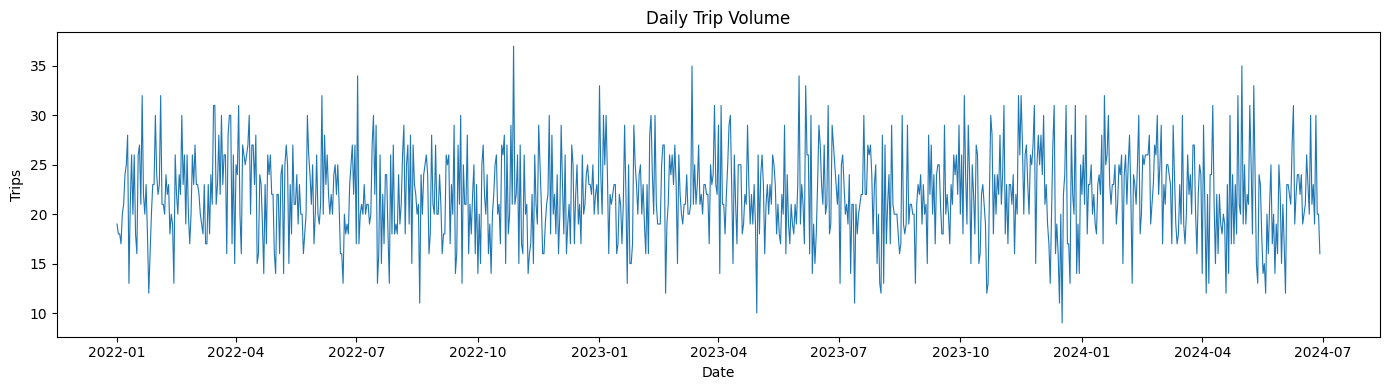

In [67]:
import matplotlib.pyplot as plt

# Daily trip volume over time
df = q("""
    SELECT DATE(requested_at) AS day, COUNT(*) AS trips
    FROM trips
    GROUP BY day
    ORDER BY day
""")
df['day'] = pd.to_datetime(df['day'])
plt.figure(figsize=(14, 4))
plt.plot(df['day'], df['trips'], linewidth=0.8)
plt.title('Daily Trip Volume')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.tight_layout()
plt.show()


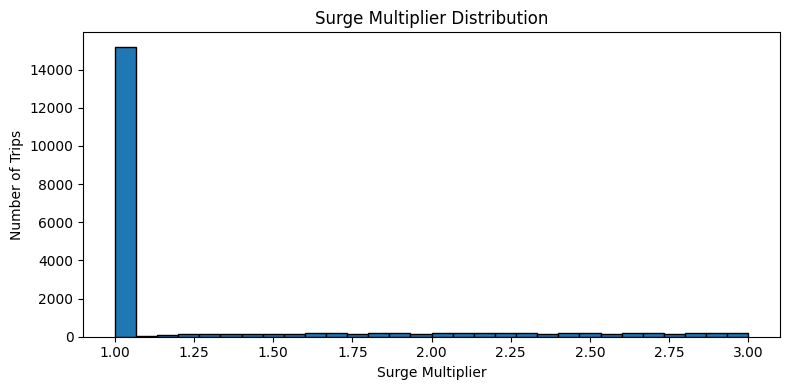

In [68]:
# Surge multiplier distribution
df2 = q("SELECT surge_multiplier FROM trips")
plt.figure(figsize=(8,4))
plt.hist(df2['surge_multiplier'], bins=30, edgecolor='black')
plt.title('Surge Multiplier Distribution')
plt.xlabel('Surge Multiplier')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()
